# 03_lightgbm.ipynb
## Training LightGBM for Web Traffic Time Series Forecasting

This notebook loads the engineered features from Notebook 02 and trains a LightGBM model to predict 60 future daily pageview values.

**Steps:**
- Load features and labels  
- Prepare dataset  
- Train LightGBM regressor  
- Predict the next 60 days  
- Compute SMAPE  
- Save outputs to the Results folder  


## Imports

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import os


## Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load engineered features and labels

From Notebook 02, we have two files:
- `features.csv` → Contains lag/rolling + metadata  
- `labels.csv` → Contains the next 60 days we want to predict  


In [3]:
# path based on where you saved your files
features_path = "/content/drive/MyDrive/CSC480/Final Project/features.csv"
labels_path = "/content/drive/MyDrive/CSC480/Final Project/labels.csv"

df_feat = pd.read_csv(features_path)
df_labels = pd.read_csv(labels_path)

df_feat.head(), df_labels.head()


(                                                Page  2015-07-01  2015-07-02  \
 0  Phabricator/Project_management_www.mediawiki.o...    1.945910    1.945910   
 1  Now_You_See_Me_es.wikipedia.org_desktop_all-ag...    5.493061    5.605802   
 2  Zürich_Hackathon_2014_www.mediawiki.org_all-ac...    1.386294    2.995732   
 3       Érythrée_fr.wikipedia.org_desktop_all-agents    6.511745    6.242223   
 4   Metallica_es.wikipedia.org_all-access_all-agents    7.336286    7.405496   
 
    2015-07-03  2015-07-04  2015-07-05  2015-07-06  2015-07-07  2015-07-08  \
 0    1.609438    1.945910    2.197225    1.945910    1.609438    0.000000   
 1    5.736572    5.429346    5.774552    5.743003    5.493061    5.468060   
 2    2.995732    3.433987    3.091042    3.218876    2.890372    5.187386   
 3    6.652863    7.060476    6.304449    6.628041    6.320768    6.204558   
 4    7.441320    7.358831    7.336286    7.363914    7.383368    7.457032   
 
    2015-07-09  ...  2016-12-25_roll_std  

## Prepare LightGBM Inputs

LightGBM requires:
- X: numeric features  
- y: regression targets  

The target is a vector of length 60 for each sample.


In [4]:
# Features are all numeric except Page and metadata, already encoded
X = df_feat.select_dtypes(include=[np.number])

# Convert labels into numpy array
y = df_labels.values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (500, 3303)
y shape: (500, 60)


## Train LightGBM

We train a regression model for each of the 60 forecast horizons.

This is because LightGBM does not natively support multi-output regression.


In [5]:
models = []
preds = []

params = {
    "objective": "regression",
    "metric": "l1",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1
}

for i in range(60):
    print(f"Training horizon {i+1}/60")

    y_target = y[:, i]
    train_data = lgb.Dataset(X, label=y_target)

    model = lgb.train(params, train_data, num_boost_round=200)
    models.append(model)

    pred = model.predict(X)
    preds.append(pred)

# Convert predictions back to (rows x 60)
pred_matrix = np.column_stack(preds)
pred_matrix.shape


Training horizon 1/60
Training horizon 2/60
Training horizon 3/60
Training horizon 4/60
Training horizon 5/60
Training horizon 6/60
Training horizon 7/60
Training horizon 8/60
Training horizon 9/60
Training horizon 10/60
Training horizon 11/60
Training horizon 12/60
Training horizon 13/60
Training horizon 14/60
Training horizon 15/60
Training horizon 16/60
Training horizon 17/60
Training horizon 18/60
Training horizon 19/60
Training horizon 20/60
Training horizon 21/60
Training horizon 22/60
Training horizon 23/60
Training horizon 24/60
Training horizon 25/60
Training horizon 26/60
Training horizon 27/60
Training horizon 28/60
Training horizon 29/60
Training horizon 30/60
Training horizon 31/60
Training horizon 32/60
Training horizon 33/60
Training horizon 34/60
Training horizon 35/60
Training horizon 36/60
Training horizon 37/60
Training horizon 38/60
Training horizon 39/60
Training horizon 40/60
Training horizon 41/60
Training horizon 42/60
Training horizon 43/60
Training horizon 44/

(500, 60)

## Compute SMAPE (Symmetric Mean Absolute Percentage Error)

Competition Metric:

SMAPE = 2 * |forecast - actual| / (|forecast| + |actual| + epsilon)

In [6]:
def smape(true, pred):
    numer = np.abs(true - pred)
    denom = np.abs(true) + np.abs(pred) + 1e-8
    return np.mean(2 * numer / denom)

smape_score = smape(df_labels.values, pred_matrix)
print("LightGBM SMAPE:", smape_score)


LightGBM SMAPE: 0.0695168151121957


## Feature Importance (From Horizon 1 Model)

We display feature importances from the first LightGBM model.


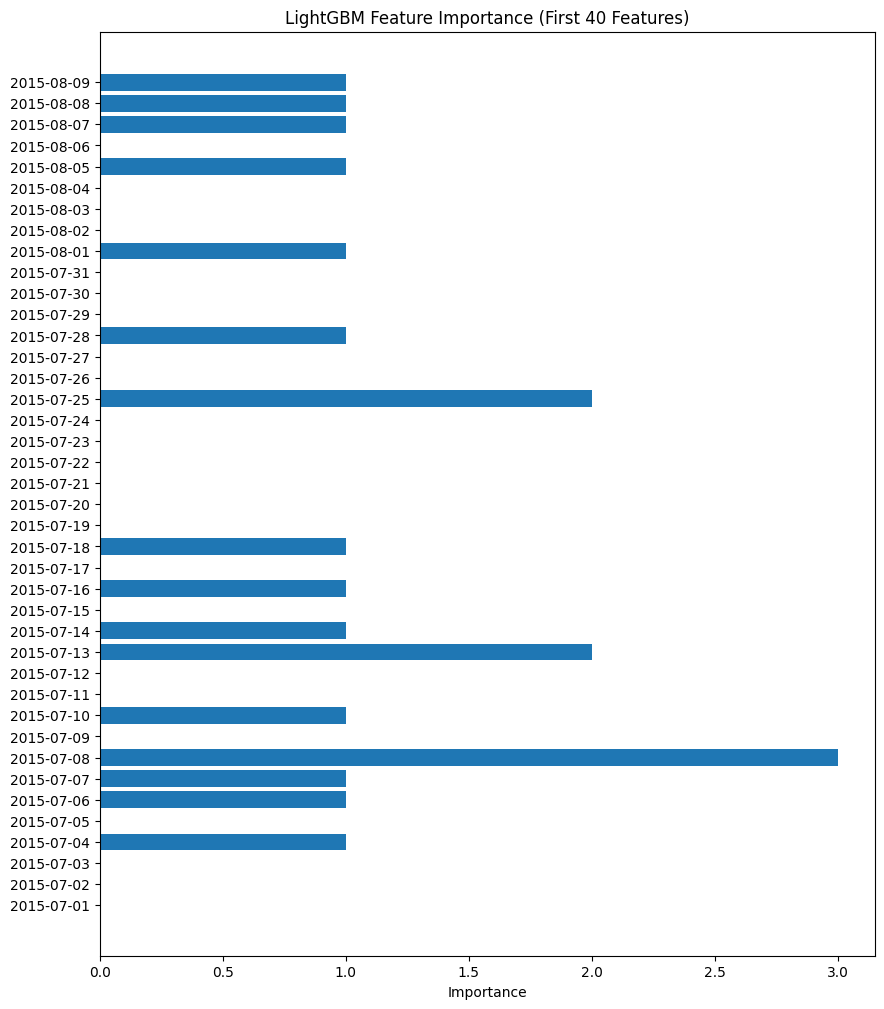

In [7]:
model0 = models[0]
importance = model0.feature_importance()
features = X.columns

plt.figure(figsize=(10, 12))
plt.barh(features[:40], importance[:40])
plt.title("LightGBM Feature Importance (First 40 Features)")
plt.xlabel("Importance")
plt.show()


## Save Model Predictions

We store:
- LightGBM predictions for 60 steps  
- SMAPE score  

This will be used later in the ensemble model (Notebook 05).


In [8]:
save_dir = "/content/drive/MyDrive/CSC480/Final Project/"
os.makedirs(save_dir, exist_ok=True)

# Save predictions matrix (rows x 60)
pred_path = save_dir + "lightgbm_predictions.csv"
np.savetxt(pred_path, pred_matrix, delimiter=",")

# Save SMAPE score
score_path = save_dir + "lightgbm_smape.txt"
with open(score_path, "w") as f:
  f.write(str(smape_score))

print("Saved LightGBM predictions to:", pred_path)
print("Saved LightGBM SMAPE score to:", score_path)


Saved LightGBM predictions to: /content/drive/MyDrive/CSC480/Final Project/lightgbm_predictions.csv
Saved LightGBM SMAPE score to: /content/drive/MyDrive/CSC480/Final Project/lightgbm_smape.txt
